# Step 1: Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Step 2: Load the Dataset

In [ ]:
df = pd.read_csv('/content/Employee Attrition.csv')

In [ ]:
# Displaying First 5 Rows

print('First 5 Rows:')
df.head()

First 5 Rows:


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [ ]:
# Displaying Last 5 Rows

print('Last 5 Rows:')
df.tail()

Last 5 Rows:


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
59593,37195,50,Female,12,Education,4414,Fair,High,Average,1,...,2,Senior,Small,35,No,No,Yes,Poor,Very High,Left
59594,6266,18,Male,4,Healthcare,8040,Fair,High,High,3,...,0,Senior,Medium,73,No,No,No,Fair,Medium,Left
59595,54887,22,Female,14,Technology,7944,Fair,High,High,0,...,2,Entry,Small,29,No,Yes,No,Good,Medium,Stayed
59596,861,23,Male,8,Education,2931,Fair,Very High,Average,0,...,0,Entry,Large,9,No,No,No,Good,Low,Left
59597,15796,56,Male,19,Technology,6660,Good,High,Average,0,...,3,Mid,Medium,81,No,No,No,Good,Low,Stayed


# Step 3: Data Understanding

In [ ]:
# Display Shape

df.shape

(59598, 24)

In [ ]:
# Check Data Types

df.dtypes

,0
Employee ID,int64
Age,int64
Gender,object
Years at Company,int64
Job Role,object
Monthly Income,int64
Work-Life Balance,object
Job Satisfaction,object
Performance Rating,object
Number of Promotions,int64


In [ ]:
# Check Data Info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

In [ ]:
# Checking Columns

df.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role',
       'Monthly Income', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Number of Promotions', 'Overtime',
       'Distance from Home', 'Education Level', 'Marital Status',
       'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure',
       'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities',
       'Company Reputation', 'Employee Recognition', 'Attrition'],
      dtype='object')

# Step 4: Remove Employee ID

In [ ]:
df_model = df.drop('Employee ID', axis = 1)

In [ ]:
# Checking Shape After Removing Employee ID Column

print('Shape After Removing Employee ID:', df_model.shape)

Shape After Removing Employee ID: (59598, 23)


In [ ]:
df_model.columns

Index(['Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income',
       'Work-Life Balance', 'Job Satisfaction', 'Performance Rating',
       'Number of Promotions', 'Overtime', 'Distance from Home',
       'Education Level', 'Marital Status', 'Number of Dependents',
       'Job Level', 'Company Size', 'Company Tenure', 'Remote Work',
       'Leadership Opportunities', 'Innovation Opportunities',
       'Company Reputation', 'Employee Recognition', 'Attrition'],
      dtype='object')

# Step 5: Separate Features(X) and Target (y)

In [ ]:
X = df_model.drop('Attrition', axis = 1)
y = df_model['Attrition']

print('Feature Selection:', X.shape)
print('Target Selection:', y.shape)

Feature Selection: (59598, 22)
Target Selection: (59598,)


# Step 6: Separate Numerical and Categorical Features

In [ ]:
numerical_features = X.select_dtypes(include = ['int64', 'float64']).columns
categorical_features = X.select_dtypes(include = ['object']).columns

print('Numerical Features:')
print(numerical_features)

print('\nCategorical Features:')
print(categorical_features)

print('\nNumber of Numerical Features:', len(numerical_features))
print('\nNumber of Categorical Features:', len(categorical_features))

Numerical Features:
Index(['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions',
       'Distance from Home', 'Number of Dependents', 'Company Tenure'],
      dtype='object')

Categorical Features:
Index(['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Overtime', 'Education Level', 'Marital Status',
       'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities',
       'Innovation Opportunities', 'Company Reputation',
       'Employee Recognition'],
      dtype='object')

Number of Numerical Features: 7

Number of Categorical Features: 15


# Step 7: Encode Target Variable

In [ ]:
y_encoded = y.map({
    'Stayed' : 0,
    'Left' : 1
})

print('Original Target Values:')
print(y.unique())

print('\nEncoded Target Values:')
print(y_encoded.unique())

print('\nTarget Distribution:')
print(y_encoded.value_counts())

Original Target Values:
['Stayed' 'Left']

Encoded Target Values:
[0 1]

Target Distribution:
Attrition
0    31260
1    28338
Name: count, dtype: int64


# Step 8: Train-Test-Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size = 0.20, random_state = 42, stratify = y_encoded)

print('X_train Shape:', X_train.shape)
print('X_test Shape:', X_test.shape)
print('y_train Shape:', y_train.shape)
print('y_test Shape:', y_test.shape)

X_train Shape: (47678, 22)
X_test Shape: (11920, 22)
y_train Shape: (47678,)
y_test Shape: (11920,)


Here, stratify means ensures both training and testing sets maintain approximately the same class distribution.

# 9. Preprocessing — Encoding and Feature Scaling

In [ ]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), categorical_features)
    ]
)

# Fit the preprocessor on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print('Processed X_train Shape:', X_train_processed.shape)
print('Processed X_test Shape:', X_test_processed.shape)

Processed X_train Shape: (47678, 56)
Processed X_test Shape: (11920, 56)


# 10. KNN Classification — Initial Model

# Train the First KNN Model

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train_processed, y_train)

print('KNN Model Trained Successfully')

KNN Model Trained Successfully


# 11. Make Predictions

In [ ]:
# Predict the target values for the test data

y_pred = knn.predict(X_test_processed)

print('Prediction completed successfully')
print('Number of predictions:', len(y_pred))

Prediction completed successfully
Number of predictions: 11920


# 12. Model Evaluation

# Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print('KNN Accuracy:', accuracy)
print('KNN Accuracy (%):', accuracy * 100)

KNN Accuracy: 0.6755872483221477
KNN Accuracy (%): 67.55872483221476


# Confusion Matrix

Confusion Matrix:
[[4253 1999]
 [1868 3800]]


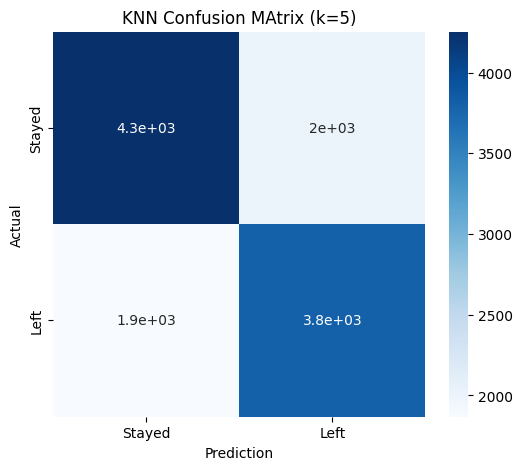

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print('Confusion Matrix:')
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot = True,
    cmap = 'Blues',
    xticklabels = ['Stayed', 'Left'],
    yticklabels = ['Stayed', 'Left']
)

plt.title('KNN Confusion MAtrix (k=5)')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

# Classification Report

In [ ]:
print('Classification Report:')
print(
    classification_report(
        y_test,
        y_pred,
        target_names = ['Stayed', 'Left']
    )
)

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.69      0.68      0.69      6252
        Left       0.66      0.67      0.66      5668

    accuracy                           0.68     11920
   macro avg       0.68      0.68      0.68     11920
weighted avg       0.68      0.68      0.68     11920



# 13. Hyperparameter Tuning using GridSearchCV

- GridSearchCV is used to systematically test multiple KNN hyperparameter combinations and select the best-performing model using cross-validation.

The preprocessing and KNN model are placed inside a Pipeline to avoid data leakage during cross-validation.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Create a pipeline with preprocessing and KNN
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier())
])

# Define the hyperparameter grid
param_grid = {
    'knn__n_neighbors': [5, 15, 25, 35, 45, 55],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Perform hyperparameter tuning
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions',
       'Distance from Home', 'Number of Dependents', 'Company Tenure'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['Gender', 'Job Role', 'Work-Life Balance', 'J...
       'Performance Rating', 'Overtime', 'Education Level', 'Marital Status',
       'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities',
       'Innovation Opportunities', 'Company Reputation',
       'Employee Recognition'],
      dtype='object'))])),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__metric': ['euclidean', 'manhattan'],
                         'knn__n_neighbors': [5, 15, 25, 35, 45, 55],
                         'knn__weights': ['uniform', 'distance']},
             scoring='f1', verbose=1)

# 14. Find the Best Parameters

In [ ]:
print('Best Parameters:')
print(grid_search.best_params_)

Best Parameters:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 55, 'knn__weights': 'distance'}


# Best Cross-Validation F1 Score

In [ ]:
print('Best Cross-Validation F1 Score:')
print(grid_search.best_score_)

Best Cross-Validation F1 Score:
0.7246960625417246


# Evaluate the Tuned KNN Model on the Test Set

The best KNN model selected by GridSearchCV is evaluated on the unseen test dataset.

In [ ]:
# Get the best KNN Pipeline
best_knn = grid_search.best_estimator_

# Make Predictions on the test set
y_pred_tuned = best_knn.predict(X_test)

# Calculate the Evaluation metrics
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

# Display results
print('Tuned KNN Test Set Performance')
print('-' * 40)
print(f'Accuracy : {accuracy_tuned:.4f}')
print(f'Precision : {precision_tuned:.4f}')
print(f'Recall : {recall_tuned:.4f}')
print(f'F1 Score  : {f1_tuned:.4f}')

Tuned KNN Test Set Performance
----------------------------------------
Accuracy : 0.7342
Precision : 0.7113
Recall : 0.7424
F1 Score  : 0.7265


# Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions made by the tuned KNN model for each class.

In [ ]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print('Confusion Matrix:')
print(cm_tuned)

Confusion Matrix:
[[4544 1708]
 [1460 4208]]


# Visualized Confusion Matrix

The confusion matrix is visualized as a heatmap to make the model's classification results easier to interpret.

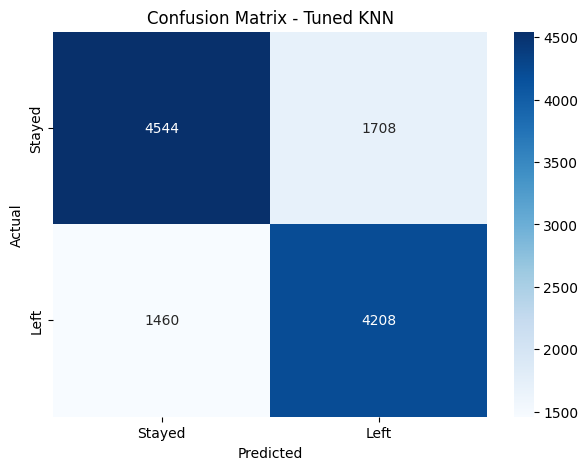

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(
    cm_tuned,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    xticklabels = ['Stayed', 'Left'],
    yticklabels = ['Stayed', 'Left']
)

plt.title('Confusion Matrix - Tuned KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report

The classification report provides precision, recall, F1-score, and support for each employee attrition class.

In [ ]:
print('Classification Report - Tuned KNN')
print('-' * 40)
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names = ['Stayed', 'Left']
    )
)

Classification Report - Tuned KNN
----------------------------------------
              precision    recall  f1-score   support

      Stayed       0.76      0.73      0.74      6252
        Left       0.71      0.74      0.73      5668

    accuracy                           0.73     11920
   macro avg       0.73      0.73      0.73     11920
weighted avg       0.74      0.73      0.73     11920



# Baseline KNN vs Tuned KNN

The baseline KNN model is compared with the tuned KNN model selected by GridSearchCV using accuracy, precision, recall, and F1-score.

In [ ]:
# Calculate baseline KNN metrics from the original predictions

accuracy_baseline = accuracy_score(y_test, y_pred)
precision_baseline = precision_score(y_test, y_pred)
recall_baseline = recall_score(y_test, y_pred)
f1_baseline = f1_score(y_test, y_pred)

# Compare Baseline KNN and Tuned KNN

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Baseline KNN': [
        accuracy_baseline,
        precision_baseline,
        recall_baseline,
        f1_baseline
    ],
    'Tuned KNN': [
        accuracy_tuned,
        precision_tuned,
        recall_tuned,
        f1_tuned
    ]
})

# Calculate improvement
comparison['Improvement'] = (
    comparison['Tuned KNN'] - comparison['Baseline KNN']
)

# Display comparison
comparison

,Metric,Baseline KNN,Tuned KNN,Improvement
0,Accuracy,0.675587,0.734228,0.058641
1,Precision,0.655285,0.711291,0.056006
2,Recall,0.670430,0.742414,0.071983
3,F1 Score,0.662771,0.726519,0.063748


# ROC-AUC Score

ROC-AUC measures how well the tuned KNN model distinguishes between employees who stayed and employees who left across different classification thresholds.

In [ ]:
# generate Probability Predictions

y_prob_tuned = best_knn.predict_proba(X_test)[:,1]

# Calculate ROC-AUC
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)
print('Tuned KNN ROC-AUC Score:', round(roc_auc_tuned, 4))

Tuned KNN ROC-AUC Score: 0.8191


The ROC Curve visualizes the performance of the tuned KNN classifier by plotting the True Positive Rate against the False Positive Rate at different classification thresholds. The Area Under the Curve (AUC) summarizes the model's overall ability to distinguish between employees who stayed and employees who left.

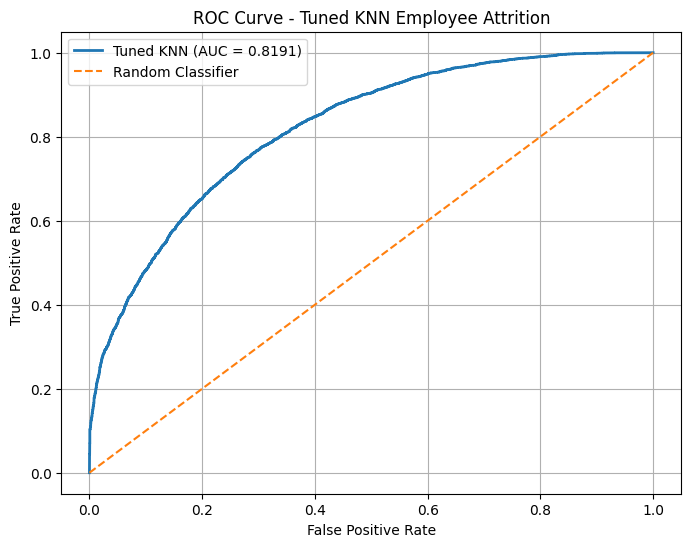

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tuned)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, linewidth=2, label=f'Tuned KNN (AUC = {roc_auc_tuned:.4f})')

plt.plot([0,1], [0,1], linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned KNN Employee Attrition')
plt.legend()
plt.grid(True)

plt.show()

# Final KNN Model Summary

The tuned KNN model selected through GridSearchCV is summarized below along with its final test-set performance.

In [ ]:
print('Final KNN Model Summary')
print('=' * 40)

print('Best Parameters:')
print(grid_search.best_params_)

print('\nCross-Validation F1 Score:')
print(f'{grid_search.best_score_:.4f}')

print('\nTest Set Performance:')
print(f'Accuracy : {accuracy_tuned:.4f}')
print(f'Precision : {precision_tuned:.4f}')
print(f'Recall : {recall_tuned:.4f}')
print(f'F1 Score : {f1_tuned:.4f}')
print(f'ROC-AUC : {roc_auc_tuned:.4f}')

Final KNN Model Summary
Best Parameters:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 55, 'knn__weights': 'distance'}

Cross-Validation F1 Score:
0.7247

Test Set Performance:
Accuracy : 0.7342
Precision : 0.7113
Recall : 0.7424
F1 Score : 0.7265
ROC-AUC : 0.8191


# New Employee Attrition Prediction

The final tuned KNN model is used to predict employee attrition for a new employee based on the employee's characteristics.

In [ ]:
# Display the feature names required for a new employee

print('Features Required for Prediction:')
print(X.columns.tolist())

Features Required for Prediction:
['Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']


# Check Categorical Feature Values

The categorical feature values are displayed to ensure that new employee inputs use the same categories as the training dataset.

In [ ]:
# Display Unique Values for all Categorical Features

for column in categorical_features:
  print(f'\n{column}:')
  print(df[column].unique())


Gender:
['Male' 'Female']

Job Role:
['Education' 'Media' 'Healthcare' 'Technology' 'Finance']

Work-Life Balance:
['Excellent' 'Poor' 'Good' 'Fair']

Job Satisfaction:
['Medium' 'High' 'Very High' 'Low']

Performance Rating:
['Average' 'Low' 'High' 'Below Average']

Overtime:
['No' 'Yes']

Education Level:
['Associate Degree' 'Master’s Degree' 'Bachelor’s Degree' 'High School'
 'PhD']

Marital Status:
['Married' 'Divorced' 'Single']

Job Level:
['Mid' 'Senior' 'Entry']

Company Size:
['Medium' 'Small' 'Large']

Remote Work:
['No' 'Yes']

Leadership Opportunities:
['No' 'Yes']

Innovation Opportunities:
['No' 'Yes']

Company Reputation:
['Excellent' 'Fair' 'Poor' 'Good']

Employee Recognition:
['Medium' 'Low' 'High' 'Very High']


# Create New Employee Input

A new employee record is created using the same 22 features used during model training.

In [ ]:
# Create a new employee record

new_employee = pd.DataFrame([{
    'Age': 30,
    'Gender': 'Male',
    'Years at Company': 5,
    'Job Role': 'Technology',
    'Monthly Income': 6000,
    'Work-Life Balance': 'Good',
    'Job Satisfaction': 'High',
    'Performance Rating': 'High',
    'Number of Promotions': 1,
    'Overtime': 'No',
    'Distance from Home': 10,
    'Education Level': "Bachelor’s Degree",
    'Marital Status': 'Married',
    'Number of Dependents': 2,
    'Job Level': 'Mid',
    'Company Size': 'Medium',
    'Company Tenure': 5,
    'Remote Work': 'Yes',
    'Leadership Opportunities': 'Yes',
    'Innovation Opportunities': 'Yes',
    'Company Reputation': 'Good',
    'Employee Recognition': 'High'
}])

# Display the new employee
new_employee

,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,...,Marital Status,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition
0,30,Male,5,Technology,6000,Good,High,High,1,No,...,Married,2,Mid,Medium,5,Yes,Yes,Yes,Good,High


# Predict Employee Attrition

The final tuned KNN model predicts whether the new employee is likely to stay or leave and provides the probability of each outcome.

In [ ]:
# Predict the new employees attrition
prediction = best_knn.predict(new_employee)[0]

# Get Prediction Probabilities
probabilities = best_knn.predict_proba(new_employee)[0]

# Convert Prediction back to the original class label
prediction_label = 'Left' if prediction == 1 else 'Stayed'

# Display Prediction
print('New Employee Attrition Prediction')
print('=' * 40)

print(f'Prediction : {prediction_label}')

print('\nPrediction Probabilities:')
print(f'Stayed : {probabilities[0]:.2%}')
print(f'Left : {probabilities[1]:.2%}')

New Employee Attrition Prediction
Prediction : Stayed

Prediction Probabilities:
Stayed : 85.57%
Left : 14.43%


# Save the Final KNN Model

The final tuned KNN pipeline, including preprocessing and the trained KNN model, is saved for future use without retraining the model.

In [ ]:
import joblib

# Save the final tuned KNN Pipeline
model_filename = 'Employee_Attrition_KNN_Model.pkl'

joblib.dump(best_knn, model_filename)

print(f'Model Saved Successfully as : {model_filename}')

Model Saved Successfully as : Employee_Attrition_KNN_Model.pkl


# Load and Verify the Saved KNN Model

The saved KNN pipeline is loaded from the `.pkl` file and tested using the same new employee data to verify that the saved model works correctly.

In [ ]:
import joblib

# Load the Saved KNN model
loaded_knn = joblib.load('Employee_Attrition_KNN_Model.pkl')

print('Model Loaded Successfully')

Model Loaded Successfully


# Verify the Loaded KNN Model

The loaded KNN model is tested using the same new employee record to confirm that the saved model produces the expected prediction and probabilities.

In [ ]:
# Predict using the loaded model

loaded_prediction = loaded_knn.predict(new_employee)[0]

loaded_probabilities = loaded_knn.predict_proba(new_employee)[0]

# Convert prediction to original class label
loaded_prediction_label = 'Left' if loaded_prediction == 1 else 'Stayed'

# Display results
print("Loaded KNN Model Prediction")
print("=" * 40)

print(f"Prediction : {loaded_prediction_label}")

print("\nPrediction Probabilities:")
print(f"Stayed : {loaded_probabilities[0]:.2%}")
print(f"Left   : {loaded_probabilities[1]:.2%}")

Loaded KNN Model Prediction
Prediction : Stayed

Prediction Probabilities:
Stayed : 85.57%
Left   : 14.43%
